In [ ]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib.pyplot import cm
from os import listdir as ls
from IPython.display import display, Markdown
import pycountry_convert as pc
import yaml as yml
import matplotlib.pyplot as plt

from emu_renewal.constants import OUTPUTS_PATH, DATA_PATH, ANALYSIS_NAMES
from emu_renewal.outputs import get_param_vals_by_analysis
from emu_renewal.plotting import plot_kde_comparison
from emu_renewal.utils import get_countries_by_continent, get_job_commits_df

set_matplotlib_formats("svg")

In [ ]:
job_path = OUTPUTS_PATH / "48930936"
# all_countries = ls(job_path)
all_countries = [iso3 for iso3 in ls(job_path) if (job_path / iso3 / "oxcgrt").exists()]  # Some countries run for mobility baseline but no CGRT data
countries_by_cont = get_countries_by_continent(all_countries)
disp_posts = {c: get_param_vals_by_analysis("dispersion_proc", job_path / c) for c in all_countries}

# Purpose
This document presents results based on the posterior distribution 
of the residual transmission scaling dispersion parameter.
This quantity governs the distribution in the change in residual scaling for transmission
from one value in the process series to the subsequent update.
As such, smaller values imply that smaller updates could still
result in good calibrations.
Lower values for this parameter can therefore be interpreted
as less dramatic changes needing to be applied through
the non-mechanistic component of the model.
As such, we interpreted mobility analysis approaches 
for which this posterior distribution of this parameter
was lower as being a more plausible representation of reality.
This is intended as a more formal quantification of the 
differences in variation in the non-mechanistic transmission scaling
presented in the previous document.

# Dispersion parameter distributions by analysis and country

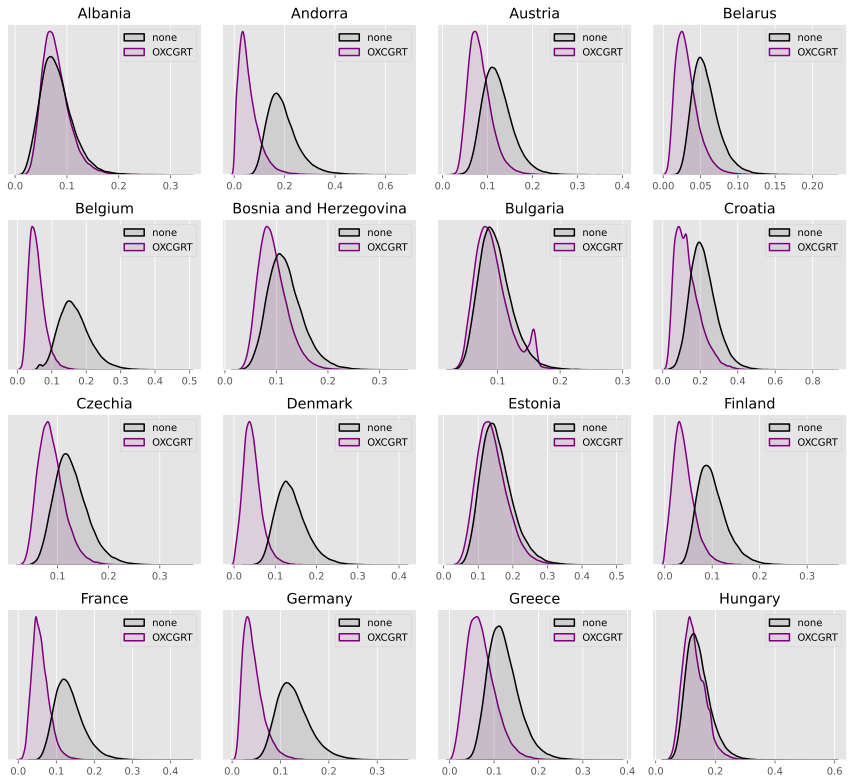

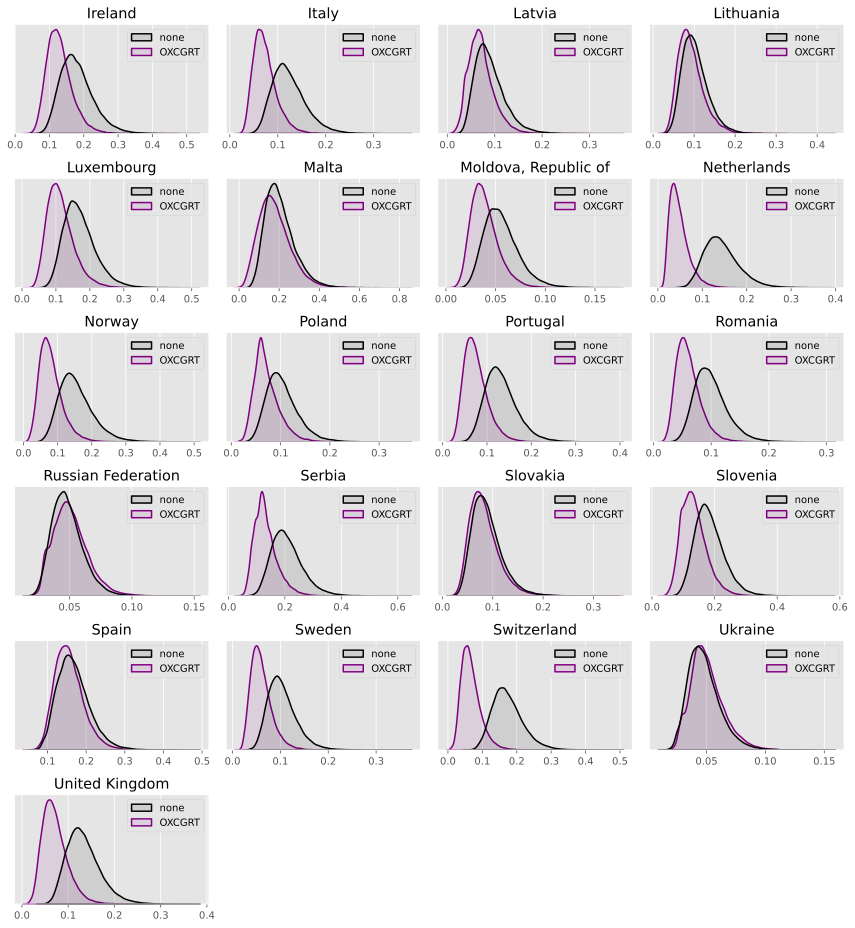

## North America

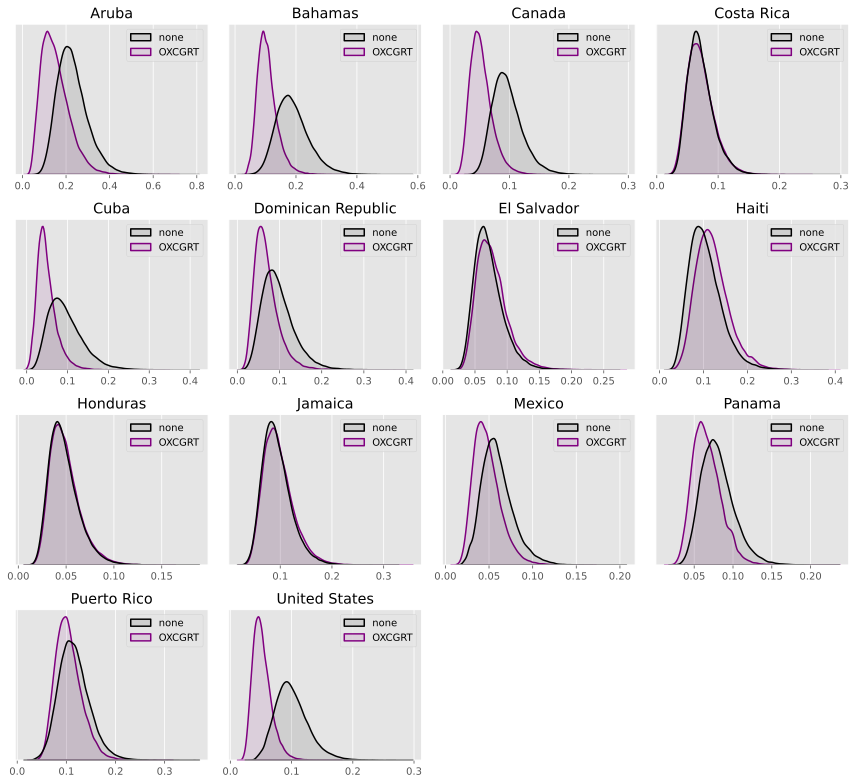

## Oceania

Note that for the countries of Oceania, a different baseline analysis was used for to compare Google and Facebook analyses against. This was done because the conclusion of the Facebook data meant that the analysis period differed from the Google analysis.

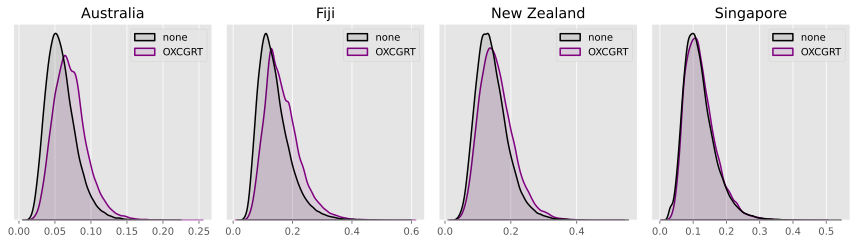

## South America

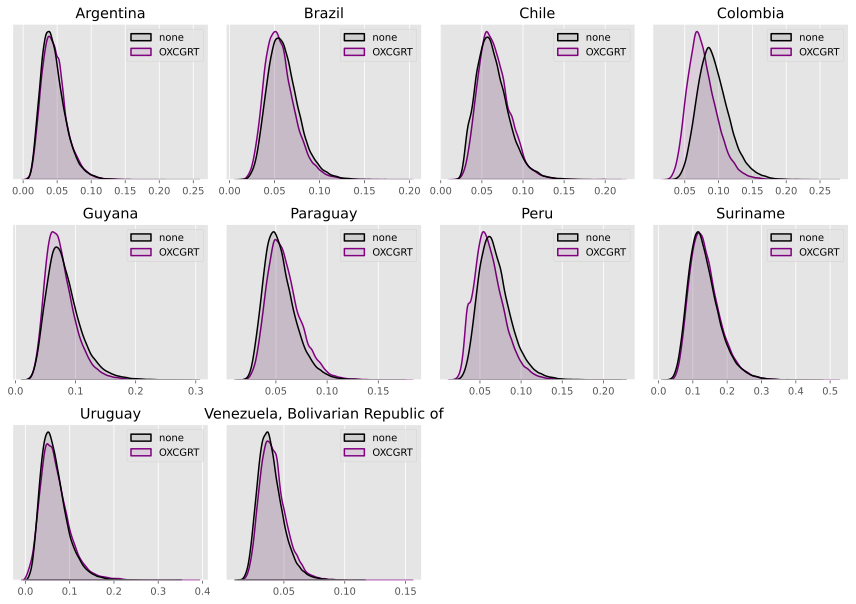

In [3]:
param = "dispersion_proc"
param_name = yml.safe_load(open(DATA_PATH / "evidence/priors.yml", "r"))["other"]["dispersion_proc"]["short_name"]
for cont, countries in countries_by_cont.items():
    cont_name = pc.convert_continent_code_to_continent_name(cont)
    display(Markdown(f"## {cont_name}"))
    title = f"Posterior distribution for {param_name} parameter, {cont_name}"
    note = (
        "Note that for the countries of Oceania, a different baseline analysis "
        "was used for to compare Google and Facebook analyses against. "
        "This was done because the conclusion of the Facebook data meant "
        "that the analysis period differed from the Google analysis."
    )
    if cont == "OC":
        display(Markdown(note))
    param_posts = {}
    for country in countries:
        param_posts[country] = get_param_vals_by_analysis(param, job_path / country)
    if cont in ["EU", "AF"]:
        eur_countries = list(param_posts.keys())
        display(plot_kde_comparison({k: param_posts[k] for k in eur_countries[:16]}))
        display(plot_kde_comparison({k: param_posts[k] for k in eur_countries[16:]}))
    else:
        display(plot_kde_comparison(param_posts))

{{< pagebreak >}}

# Commits used for analyses
For reproducbility, the following table gives the (short) commit SHA for each analysis.

In [4]:
Markdown(get_job_commits_df(job_path, all_countries).to_markdown())

|                                   | no mobility   | Google mobility   | Facebook tiles visited mobility   | Facebook single tile mobility   | OxCGRT   |
|:----------------------------------|:--------------|:------------------|:----------------------------------|:--------------------------------|:---------|
| Afghanistan                       | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Albania                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Algeria                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Andorra                           | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Angola                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Argentina                         | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Aruba                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Australia                         | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Austria                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Azerbaijan                        | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Bahamas                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Bahrain                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Bangladesh                        | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Belarus                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Belgium                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Benin                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Bosnia and Herzegovina            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Brazil                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Bulgaria                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Burkina Faso                      | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Cabo Verde                        | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Cameroon                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Canada                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Chile                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Colombia                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Congo                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Costa Rica                        | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Croatia                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Cuba                              | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Cyprus                            | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Czechia                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Côte d'Ivoire                     | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Denmark                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Dominican Republic                | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Egypt                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| El Salvador                       | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Estonia                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Eswatini                          | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Ethiopia                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Fiji                              | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Finland                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| France                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Gabon                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Georgia                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Germany                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Greece                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Guinea                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Guyana                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Haiti                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Honduras                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Hungary                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| India                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Indonesia                         | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Iran, Islamic Republic of         | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Iraq                              | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Ireland                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Israel                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Italy                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Jamaica                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Japan                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Jordan                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Kenya                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Korea, Republic of                | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Kuwait                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Latvia                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Lebanon                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Lesotho                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Liberia                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Libya                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Lithuania                         | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Luxembourg                        | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Madagascar                        | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Malawi                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Malaysia                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Mali                              | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Malta                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Mexico                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Moldova, Republic of              | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Morocco                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Mozambique                        | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Nepal                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Netherlands                       | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| New Zealand                       | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Nigeria                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Norway                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Oman                              | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Pakistan                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Palestine, State of               | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Panama                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Paraguay                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Peru                              | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Philippines                       | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Poland                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Portugal                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Puerto Rico                       | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Qatar                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Romania                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Russian Federation                | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Rwanda                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Saudi Arabia                      | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Senegal                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Serbia                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Singapore                         | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Slovakia                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Slovenia                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Somalia                           | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| South Africa                      | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| South Sudan                       | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Spain                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Sri Lanka                         | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Sudan                             | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Suriname                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Sweden                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Switzerland                       | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Syrian Arab Republic              | 51da984       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Togo                              | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Tunisia                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Türkiye                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Ukraine                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| United Arab Emirates              | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| United Kingdom                    | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| United States                     | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Uruguay                           | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Venezuela, Bolivarian Republic of | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Yemen                             | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Zambia                            | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |
| Zimbabwe                          | 83868d3       | no analysis       | no analysis                       | no analysis                     | f6b3aba  |